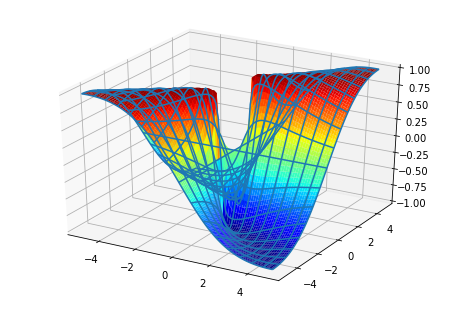

In [4]:

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import pylab
import numpy as np
import mpmath
mpmath.dps = 5

# Use instead of arg for a continuous phase
def arg2(x):
    return mpmath.sin(mpmath.arg(x))

#f = lambda z: abs(mpmath.loggamma(z))
#f = lambda z: arg2(mpmath.exp(z))
#f = lambda z: abs(mpmath.besselj(3,z))
f = lambda z: arg2(z^2+2)

fig = pylab.figure()
ax = Axes3D(fig)
X = np.arange(-5, 5, 0.125)
Y = np.arange(-5, 5, 0.125)
X, Y = np.meshgrid(X, Y)
xn, yn = X.shape
W = X*0
for xk in range(xn):
    for yk in range(yn):
        try:
            z = complex(X[xk,yk],Y[xk,yk])
            w = float(f(z))
            if w != w:
                raise ValueError
            W[xk,yk] = w
        except (ValueError, TypeError, ZeroDivisionError):
            # can handle special values here
            pass
    #print(xk, xn)

# can comment out one of these
ax.plot_surface(X, Y, W, rstride=1, cstride=1, cmap=cm.jet)
ax.plot_wireframe(X, Y, W, rstride=5, cstride=5)

pylab.show()